# Model Validation for Energy Poverty Prediction

This notebook performs the validation of multiple machine learning models used to predict energy poverty. The goal of this validation process is to evaluate the performance of different classification models using the prepared dataset.

The dataset is first loaded and preprocessed, after which it is divided into training and testing sets. Multiple machine learning models are then trained and evaluated using standard classification metrics.

The models evaluated in this notebook include:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Support Vector Machine (SVM)
- Gradient Boosting Classifier

The evaluation of these models is performed using metrics such as Accuracy, Precision, Recall, F1 Score, and Confusion Matrix.

In [2]:
import pandas as pd
df = pd.read_csv("Cleaned_dataset_energy_poverty.csv")

In [3]:
df["energy_score"] = (
    (df["cfuel"] == 1).astype(int) +
    (df["ipollut"] == 1).astype(int) +
    (df["resp_disease"] == 1).astype(int)
)

df["Energy_Poverty"] = (df["energy_score"] >= 2).astype(int)

In [4]:
X = df.drop(columns=["Energy_Poverty","energy_score","hh"])
y = df["Energy_Poverty"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

## Feature Scaling

Feature scaling is applied using the StandardScaler method to normalize the dataset. Scaling ensures that all features contribute equally to the model training process and prevents features with larger numeric ranges from dominating the learning process.

This step is particularly important for models such as Logistic Regression and Support Vector Machines, which are sensitive to feature scaling.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training and Validation

In this step, multiple machine learning classification models are trained using the training dataset and evaluated using the testing dataset.

The models used in this validation process include:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Support Vector Machine (SVM)
5. Gradient Boosting Classifier

Each model is evaluated using the following performance metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

These metrics help assess the effectiveness of each model in predicting energy poverty.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():

    print("\n==============================")
    print(name)
    print("==============================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Accuracy:", accuracy)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
Accuracy: 0.8666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       131
           1       0.45      0.26      0.33        19

    accuracy                           0.87       150
   macro avg       0.68      0.61      0.63       150
weighted avg       0.84      0.87      0.85       150

Confusion Matrix:
[[125   6]
 [ 14   5]]

Decision Tree
Accuracy: 0.9933333333333333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       131
           1       0.95      1.00      0.97        19

    accuracy                           0.99       150
   macro avg       0.97      1.00      0.99       150
weighted avg       0.99      0.99      0.99       150

Confusion Matrix:
[[130   1]
 [  0  19]]

Random Forest
Accuracy: 0.8866666666666667

Classification Report:
              precision    recall  f1-score   support


## Train-Test Split

To properly evaluate the performance of the machine learning models, the dataset is divided into training and testing subsets.

- **70% of the data** is used for training the models.
- **30% of the data** is used for testing and validation.

This approach ensures that the models are evaluated on unseen data, allowing for a more reliable assessment of their predictive performance.

In [10]:
for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.8666666666666667
Decision Tree Accuracy: 0.9866666666666667
Random Forest Accuracy: 0.8866666666666667
SVM Accuracy: 0.8733333333333333
Gradient Boosting Accuracy: 0.9933333333333333


## Model Performance Comparison

To visually compare the performance of the different machine learning models, a bar chart is created based on their accuracy scores.

This visualization provides a clear comparison of how each model performs on the testing dataset and helps identify the best-performing model for predicting energy poverty.

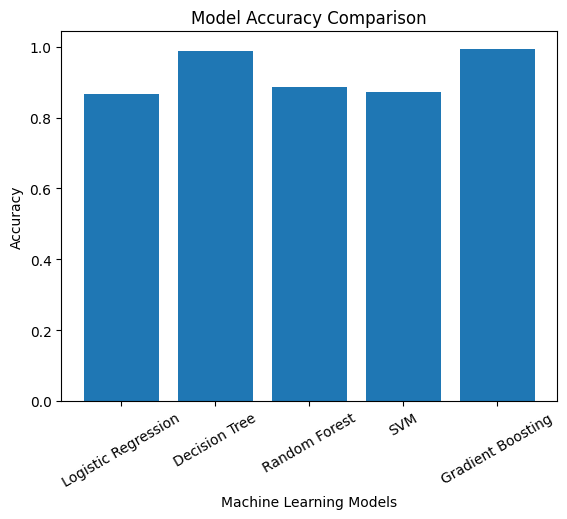

In [11]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "Gradient Boosting"
]

accuracies = [
    0.8667,
    0.9867,
    0.8867,
    0.8733,
    0.9933
]

plt.figure()

plt.bar(models, accuracies)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)

plt.show()

## Conclusion

The performance of five machine learning models was evaluated to determine their effectiveness in predicting energy poverty.

The models tested included Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), and Gradient Boosting.

Based on the evaluation results, the Gradient Boosting classifier achieved the highest accuracy among all models, indicating its strong ability to capture patterns in the dataset and accurately classify households experiencing energy poverty.

The results demonstrate that advanced ensemble methods such as Gradient Boosting can significantly improve predictive performance compared to traditional classification models.

These findings highlight the potential of machine learning techniques in identifying and analyzing energy poverty conditions using household-level data.